# SpaPath NSCLC workflow

This notebook follows one linear workflow: load the single-cell reference and FOV_3 disease data, preprocess and build graphs, learn initial embeddings, cluster, integrate, detect pathological regions, and construct the all-gene disease dataset.

## 0. Setup

In [1]:
from pathlib import Path
import sys
import warnings

import scanpy as sc
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import spapath_model
import spapath_utils

warnings.filterwarnings("ignore")

In [2]:
DATASET_ID = "NSCLC"
REFERENCE_SECTION = "scRNA_Sample1"
DISEASE_SECTION = "FOV_7"
DEVICE = "cuda"
SEED = 123

DATA_ROOT = Path("/share/data/wuyd")
PROCESSED_DIR = DATA_ROOT / "SpaPAD" / "processed" / DATASET_ID
OUTPUT_DIR = DATA_ROOT / "SpaPAD" / "outs" / DATASET_ID
FIGURE_DIR = OUTPUT_DIR / "fig"

for output_path in (OUTPUT_DIR, FIGURE_DIR):
    spapath_utils.create_dir(output_path)

adata_type_map = {
    REFERENCE_SECTION: "sc",
    DISEASE_SECTION: "ST",
}
sections = list(adata_type_map)

CELLTYPE_PALETTE = {
    "B-cell": "#006E54",
    "NK": "#00A381",
    "T CD4 memory": "#38B48B",
    "T CD4 naive": "#00A497",
    "T CD8 memory": "#80ABA9",
    "T CD8 naive": "#5C9291",
    "Treg": "#478384",
    "endothelial": "#6E7955",
    "epithelial": "#5A544B",
    "fibroblast": "#F6BFBC",
    "mDC": "#F5B1AA",
    "macrophage": "#F5B199",
    "mast": "#E597B2",
    "monocyte": "#EE827C",
    "neutrophil": "#DEB068",
    "pDC": "#BF794E",
    "plasmablast": "#A59564",
    "tumor": "#96514D",
}

/share/data/wuyd/SpaPAD/outs/NSCLC has been created or already exists.
/share/data/wuyd/SpaPAD/outs/NSCLC/fig has been created or already exists.


## 1. Read reference and disease data

In [3]:
reference_adata = sc.read_h5ad(PROCESSED_DIR / f"{REFERENCE_SECTION}.h5ad")
disease_adata = sc.read_h5ad(PROCESSED_DIR / f"{DISEASE_SECTION}.h5ad")

## 2. Preprocess data and build graphs

In [4]:
batch_list = [reference_adata, disease_adata]
adata_full, disease_adata_all_genes = spapath_utils.preprocess(
    adata_list=batch_list,
    adata_type_map=adata_type_map,
    full_num_hvgs=3000,
    min_genes_qc=10,
    min_cells_qc=10,
)

adata_full = spapath_utils.build_graph_GAT_plus(
    adata_full=adata_full,
    adata_type_map=adata_type_map,
    K=8,
    img_threshold=0.0,
)

shape of adata 0 before quality control: (3656, 33525)
shape of adata 0 after quality control: (3656, 15189)
shape of adata 1 before quality control: (3677, 960)
shape of adata 1 after quality control: (3677, 960)
Find 806 shared genes among datasets.
Normalize data...
Find 806 shared highly variable genes among datasets.
Start building graphs...
Skipping spatial graph for batch scRNA_Sample1 (sc)
Building sparse graph for batch FOV_7 (ST) using NearestNeighbors...
  Average neighbors for Slice FOV_7: 8.00


## 3. Learn initial embeddings

In [5]:
model = spapath_model.Model(
    adata_full=adata_full,
    adata_type_map=adata_type_map,
    lr_pre=1e-4,
    lr=1e-4,
    n_pre_training_steps=500,
    n_training_steps=300,
    device=DEVICE,
    seed=SEED,
)

adata_full = model.initial_embedding()

Pretrain slice 1: 100%|██████████| 500/500 [00:02<00:00, 176.05it/s]


## 4. Cluster observations

In [6]:
adata_full = model.clustering(
    init_res=1.5,
    intopk=40,
)

There are 18 initial clusters for Slice - 0
There are 18 initial clusters for Slice - 1
There are 9 clusters for Slice - 0 after merging.
There are 5 clusters for Slice - 1 after merging.
[Cluster size] Slice 0 after merge: 0:398(0.109), 1:1225(0.335), 2:773(0.211), 3:234(0.064), 4:328(0.090), 5:276(0.075), 6:162(0.044), 7:176(0.048), 8:84(0.023)
[Cluster size] Slice 1 after merge: 0:830(0.226), 1:1459(0.397), 2:311(0.085), 3:888(0.242), 4:189(0.051)
Skip Deep Embedded Clustering (DEC) fine-tuning.
Add cluster size diagnostics into adata_full.uns['cluster_size_diagnostics'].


## 5. Integrate reference and disease data

In [7]:
adata_full = model.integrate(topk=40)

  0%|          | 0/300 [00:00<?, ?it/s]

Integration step 0: matched target clusters [3]; far-cluster pool [1].


  0%|          | 1/300 [00:00<00:53,  5.58it/s]

Training step 0: reconstruction=13.2563, inter-cluster=2.0635, intra-cluster=7.4401, geometry=778.2948.


 36%|███▋      | 109/300 [00:02<00:04, 44.73it/s]

Integration step 100: matched target clusters [0, 3]; far-cluster pool [1, 2, 4].
Training step 100: reconstruction=13.4526, inter-cluster=0.8810, intra-cluster=7.4660, geometry=125.5028.


 70%|██████▉   | 209/300 [00:04<00:02, 44.07it/s]

Integration step 200: matched target clusters [0, 3]; far-cluster pool [1, 2, 4].
Training step 200: reconstruction=13.0637, inter-cluster=0.8542, intra-cluster=7.4496, geometry=87.3539.


100%|██████████| 300/300 [00:06<00:00, 44.12it/s]


Integration completed; cell embeddings, gene embeddings, and cell-gene distances were stored.


## 6. Detect pathological regions

In [8]:
adata_full = spapath_utils.detection(
    adata=adata_full,
    embed="cell_embed",
    section_ids=sections,
    label_core="Pathological regions",
    label_other="Healthy-like regions",
    core_types=["tumor"],
    celltype_key="CellType",
    batch_key="batch",
    seed=SEED,
    neighbors=30,
    threshold=0.05,
    strategy="individual",
)

display(adata_full.uns["result"])

Detection completed at the observation level.


,DTS,F1,Balanced Accuracy,Accuracy,Precision,Recall,specificity
0,0.934627,0.935917,0.933336,0.932554,0.881694,0.997247,0.869425


Detection UMAP was saved to /share/data/wuyd/SpaPAD/outs/NSCLC/fig/FOV_7_detection_umap.png.


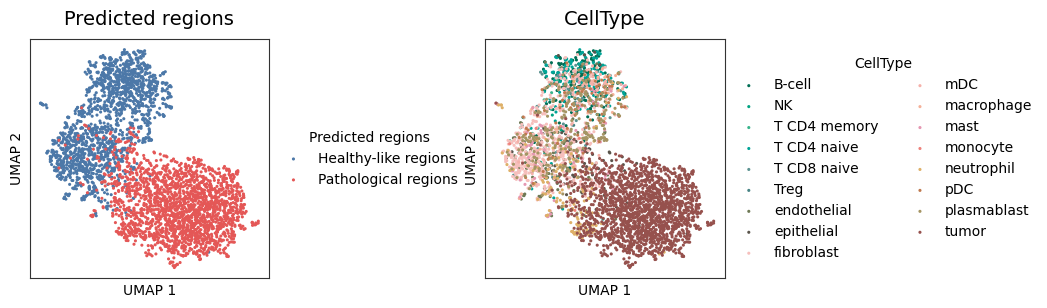

In [9]:
detection_figure = spapath_utils.plot_detection_umap(
    adata=adata_full,
    embed="cell_embed",
    section_id=DISEASE_SECTION,
    batch_key="batch",
    label_key="pred_label",
    celltype_key="CellType",
    celltype_palette=CELLTYPE_PALETTE,
    seed=SEED,
    point_size=5,
    save=FIGURE_DIR / f"{DISEASE_SECTION}_detection_umap.png",
)

## 7. Build the all-gene disease dataset

In [10]:
disease_data = spapath_utils.build_disease_data(
    adata_full=adata_full,
    disease_adata_all_genes=disease_adata_all_genes,
    disease_section=DISEASE_SECTION,
)